## Overall realted to

- (query) --> (data) --> (analysis) --> (writing)

```python
# query:
query = input("Enter your query:   ")

# need to process convert query into function argument7
def get_data(ticker):
  """ticker based on coverted user query"""
  data = yf.download(ticker)
  return data[['Close']]

def analysis(ticker):
  from sklearn.decomposition import PCA
  data = get_data(ticker)
  pca = PCA(0.95)
  return pca.fit_transform(data)

# crewai/autogen/langgraph/openai(Agent, Swarm)
#get_data ---> function (json): tool

from openai import Openai

client = Openai()
prompt = None # wll be replaced

response = client.beta.chat.completition.parse(
  model = "gpt-4o-mini"
  messages = [{"role":"system" , "content": "very helful agent",
              "role":"user", "content": prompt}],

  #tools
  # response format
  # functions


```

## PCA
for PCA manual  [see](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

In [ ]:
#!pip install -q yfinance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns; sns.set()

from sklearn.decomposition import PCA

In [ ]:
it_tickers = ['AAPL', 'CSCO', 'IBM', 'INTC', 'MMM', 'MSFT', 'VZ']

data = pd.DataFrame([])
for ticker in it_tickers:
    data[ticker]= yf.download(ticker)['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
#data.describe()
data = data.dropna()

In [ ]:
data.head()

,AAPL,CSCO,IBM,INTC,MMM,MSFT,VZ
Date,,,,,,,
1990-02-16,0.301339,0.077257,24.737095,1.250000,16.696280,0.680556,20.459593
1990-02-20,0.299107,0.079861,24.587715,1.210938,16.356606,0.696181,19.616478
1990-02-21,0.303571,0.078125,25.065727,1.214844,16.173704,0.667535,19.504063
1990-02-22,0.294643,0.078993,24.677341,1.210938,16.199833,0.669271,19.475958
1990-02-23,0.296875,0.078559,24.527964,1.203125,16.252090,0.677083,19.532166


<Axes: xlabel='Date'>

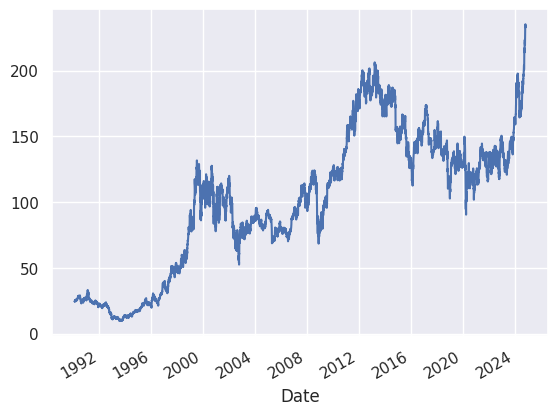

In [ ]:
data['IBM'].plot(label='IBM')
#data_dj.plot(secondary_y=True, label='DJIA')
#plt.legend()

In [ ]:
#btc = yf.download('BTC-USD')['Close']
btc.plot(backend='plotly')

In [ ]:
df = data.apply(lambda x: (x-x.mean())/x.std())
df_corr = df.head().corr()

- `explained_variance_` : The amount of variance explained by each of the selected components.
    - Equal to n_components largest eigenvalues of the covariance matrix of X.    
<br>      

-  `explained_variance_ratio_` : Percentage of variance explained by each of the selected components.

In [ ]:
#pca = PCA(n_components)

In [ ]:
pca = PCA().fit(df)

In [ ]:
pca.explained_variance_.sort()

In [ ]:
pca.explained_variance_ratio_

array([0.75198666, 0.11156446, 0.07566723, 0.0291231 , 0.02202961,
       0.00703872, 0.00259021])

In [ ]:
np.cumsum(pca.explained_variance_ratio_)

array([0.75198666, 0.86355112, 0.93921835, 0.96834146, 0.99037107,
       0.99740979, 1.        ])

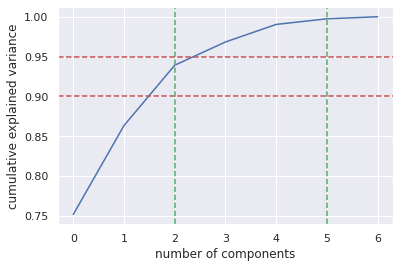

In [ ]:
pca = PCA().fit(df)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.axhline(0.9, c='r', ls='--' )
plt.axhline(0.95, c='r', ls='--' )
plt.axvline(2, c='g', ls='--' )
plt.axvline(5, c='g', ls='--' )

### `n_components`: `PCA(0.9) or PCA(n_components=3)`

-  **Want to keep explained variance ratio 90%. How many components do we need?**

In [ ]:
pca_n = PCA(0.95).fit(df)
pca_n.n_components_

4

In [ ]:
pca = PCA(n_components=4)
pca.fit(df)

PCA(copy=True, iterated_power='auto', n_components=4, random_state=None,
    svd_solver='auto', tol=0.0, whiten=False)

In [ ]:
print(pca.components_)
#print(pca.explained_variance_ratio_);

[[ 0.36318565  0.38547537  0.32646056  0.40368981  0.38142189  0.38716669
   0.3931695 ]
 [ 0.56839368 -0.22532113 -0.57492318 -0.12008428  0.00854734  0.49240415
  -0.1966398 ]
 [-0.24602293  0.48366775 -0.50427423  0.42496834 -0.49561153  0.08263092
   0.13486651]
 [-0.09454508  0.3988505  -0.1060687   0.17012794  0.46969604 -0.09811567
  -0.74936264]]


- **`fit_transform`: fit the model and apply dimensionality reduction: principal components**

In [ ]:
projected = pca.fit_transform(df)

In [ ]:
# chekc fit_transform got the original dimension
print(df.shape, projected.shape)

(7859, 7) (7859, 4)


### Principal components vs. time series

In [ ]:
# correlation b/w
corr =[np.corrcoef(projected[:,0],df[ticker])[0,1] for ticker in df.columns]
corr = (pd.Series(corr, index = df.columns))

In [ ]:
corr.sort_values(ascending=False)  # INTC: Intel, VZ: Verizon, HD: Home Depot, V: Visa, JNJ: Johnson and Johnson

INTC    0.926194
VZ      0.902057
MSFT    0.888284
CSCO    0.884404
MMM     0.875104
AAPL    0.833264
IBM     0.749005
dtype: float64

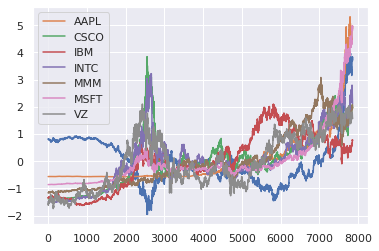

In [ ]:
plt.plot(np.arange(len(projected)), projected[:,1])
for ticker in df.columns:
    plt.plot(np.arange(len(projected)), df[ticker], label=ticker)
plt.legend()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

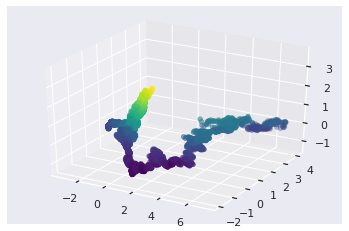

In [ ]:
%matplotlib widget

from mpl_toolkits import mplot3d
ax = plt.axes(projection='3d')
ax.scatter3D(projected[:,0], projected[:,1], projected[:,2], c =projected[:,2], cmap='viridis');

In [ ]:
!pip install -q ipympl

     |████████████████████████████████| 112kB 8.8MB/s 


In [ ]:
%matplotlib widget

plt.scatter(projected[:,0], projected[:,1],  c = projected[:,2], cmap='viridis')
plt.colorbar()
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [ ]:
cov = np.cov(df, rowvar=False)
cov.shape

(7, 7)

In [ ]:
evals, evecs = np.linalg.eig(cov)

In [ ]:
df_m  = df - np.mean(df)
df_m.dot(evecs); # the same as projected

In [ ]:
projected[:,0]

array([-3.16449765, -3.19783197, -3.20031703, ...,  6.32819091,
        6.19883577,  6.44784898])

Normalized eigenvalue is the same as `explained_variance_ratio`

In [ ]:
print(pca.explained_variance_ratio_)

[0.75198666 0.11156446 0.07566723 0.0291231 ]


- Now we reduce 30 listed equity return to 3 components (increase the components up to 4 would be possible)
- It has been argued that the first component is related with market portfolio or market risk premium as argued in CAPM or factor model

**Want to compare pca_1(projected[:,]) with DJIA**

In [ ]:
dji = yf.download('^DJI')[['Close']]

[*********************100%***********************]  1 of 1 completed


In [ ]:
dji = dji.dropna()
#np.std(data_dj)

In [ ]:
dji = dji.apply(lambda x: (x-x.mean())/x.std())

In [ ]:
df_tmp = pd.DataFrame(projected[:, 0]).set_index(df.index)

In [ ]:
df_tmp = df_tmp.merge(dji, left_index=True, right_index=True)
df_tmp.columns = ['pca1', 'dji']

In [ ]:
df_tmp

,pca1,dji
Date,,
1992-01-02,-3.065040,-1.382120
1992-01-03,-3.065508,-1.377787
1992-01-06,-3.080634,-1.377995
1992-01-07,-3.071928,-1.377296
1992-01-08,-3.069940,-1.377430
...,...,...
2021-04-22,7.069446,3.181237
2021-04-23,7.080013,3.215130
2021-04-26,7.035534,3.205909


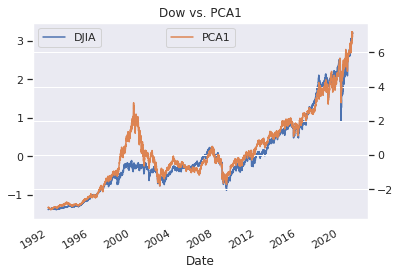

In [ ]:
%matplotlib inline
df_tmp.dji.plot(label='DJIA')
plt.legend(loc=8)
df_tmp.pca1.plot(secondary_y=True, label='PCA1');
plt.legend(loc=9)
plt.title("Dow vs. PCA1");

# X_reconstructed = pca.inverse_transform(X_pca)

## What are pca's?

In [ ]:
import matplotlib as mpl
mpl_dates = [mpl.dates.date2num(date) for date in df_tmp.index ]

In [ ]:
tmp = pd.DataFrame(projected[:, 1:3]).set_index(df.index)
tmp.columns = ['pca2', 'pca3']
df_tmp = df_tmp.merge(tmp, left_index=True, right_index=True)

In [ ]:
df_tmp['mdate'] = mpl.dates.date2num(df_tmp.index)

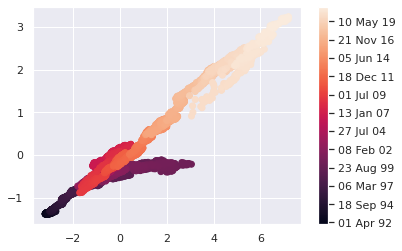

In [ ]:
plt.scatter(df_tmp['pca1'], df_tmp['dji'], c= df_tmp['mdate'])
plt.colorbar(ticks=mpl.dates.DayLocator(interval=900),
              format=mpl.dates.DateFormatter('%d %b %y'));

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

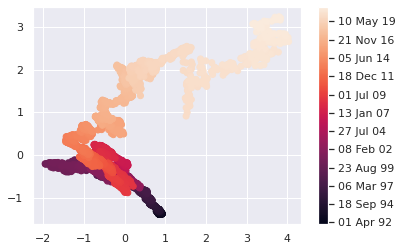

In [ ]:
%matplotlib widget
plt.scatter(df_tmp['pca2'], df_tmp['dji'], c= df_tmp['mdate'])
plt.colorbar(ticks=mpl.dates.DayLocator(interval=900),
              format=mpl.dates.DateFormatter('%d %b %y'));

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

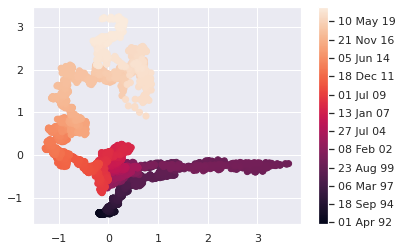

In [ ]:
%matplotlib widget
plt.scatter(df_tmp['pca3'], df_tmp['dji'], c= df_tmp['mdate'])
plt.colorbar(ticks=mpl.dates.DayLocator(interval=900),
              format=mpl.dates.DateFormatter('%d %b %y'));
plt.show()